In [ ]:
# Fig. 1B

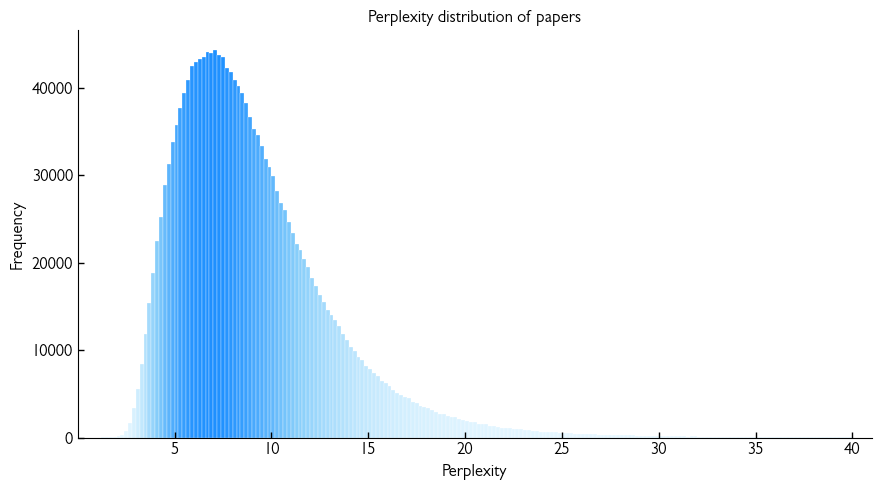

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

file_path = """/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_llama3_natural_and_social_sciences.parquet"""
all_data = pd.read_parquet(file_path)

all_data = all_data[all_data['perplexity'] <= 40]

min_value = np.floor(all_data['perplexity'].min())
max_value = np.ceil(all_data['perplexity'].max())
bin_edges = np.arange(min_value, max_value + 0.2, 0.2)

counts, bins = np.histogram(all_data['perplexity'], bins=bin_edges)

light_blue = '#E6F7FF'
medium_blue = '#87CEFA'
dark_blue = '#1E90FF'
cmap = mcolors.LinearSegmentedColormap.from_list('sky_blue_gradient', [light_blue, medium_blue, dark_blue])
norm = mcolors.Normalize(vmin=0, vmax=counts.max())
colors = [cmap(norm(count)) for count in counts]

plt.figure(figsize=(9, 5))
for i in range(len(counts)):
    plt.bar(bins[i], counts[i], width=0.2, align='edge', color=colors[i], edgecolor='white', linewidth=0.2)

plt.title('Perplexity distribution of papers', fontsize=12)
plt.xlabel('Perplexity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax = plt.gca()
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)
ax.tick_params(axis='both', which='major', labelsize=12)

x_ticks = ax.get_xticks()
x_labels = ax.get_xticklabels()
x_ticks_filtered = [tick for tick in x_ticks if tick != 0]
ax.set_xticks(x_ticks_filtered)

ax.tick_params(axis='y', which='major', bottom=False, top=False, left=True, right=False)
y_ticks = ax.get_yticks()
for tick in y_ticks:
    if tick == 0:
        ax.axhline(y=0, color='white', linewidth=0)

plt.grid(False)
plt.tight_layout()
plt.xlim(0, 41)
# 8. 显示图表
plt.show()

In [ ]:
# Fig. 2B

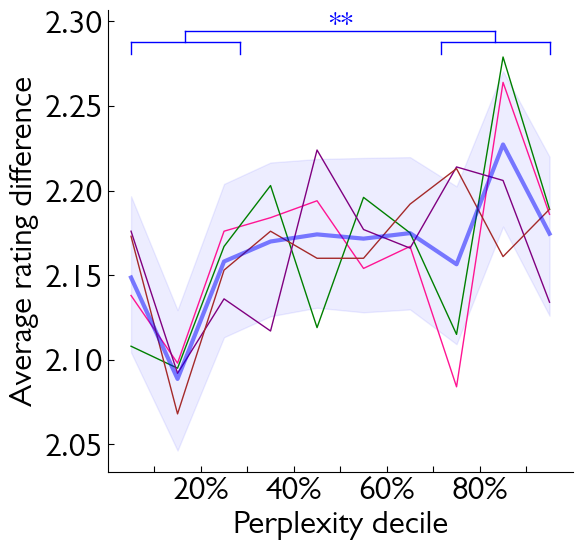

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_paths = [
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]
file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B'] # , 'Llama-2-7B'
color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))
all_data = []

for file_idx, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    df = pd.read_parquet(file_path)
    df['model'] = label
    df['perplexity_group'] = pd.qcut(df['perplexity'], q=10, labels=False)
    all_data.append(df)
    group_stats = df.groupby('perplexity_group').agg({
        'rating_max-min': ['mean', 'std'],
        'perplexity': ['min', 'max']
    }).round(3)
    x_values = [(i + 0.5) * 10 for i in range(10)]
    y_values = group_stats['rating_max-min']['mean']
    ax.plot(x_values, y_values, linewidth=1, markersize=8, alpha=1, color=color_map[label])

combined_data = pd.concat(all_data, ignore_index=True)

x_values = [(i + 0.5) * 10 for i in range(10)]

weighted_avg = np.zeros(10)
for i in range(10):
    bin_data = combined_data[combined_data['perplexity_group'] == i]
    if not bin_data.empty:
        weighted_avg[i] = bin_data['rating_max-min'].mean()

n_bootstraps = 1000
bootstrap_results = np.zeros((n_bootstraps, 10))

for b in range(n_bootstraps):
    for i in range(10):
        bin_data = combined_data[combined_data['perplexity_group'] == i]
        if len(bin_data) > 0:
            bootstrap_sample = bin_data.sample(n=len(bin_data), replace=True)
            bootstrap_results[b, i] = bootstrap_sample['rating_max-min'].mean()
        else:
            bootstrap_results[b, i] = np.nan

ci_lower = np.percentile(bootstrap_results, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_results, 97.5, axis=0)

ax.plot(x_values, weighted_avg, linewidth=3, color='blue', alpha=0.5)

ax.fill_between(x_values, ci_lower, ci_upper, color='blue', alpha=0.07)

left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.007
top_bracket_height = 0.007
vertical_gap = 0

y_max = max(max(weighted_avg), max(ci_upper))
y_base = y_max + 0.01

# 定义左右方框的位置
x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

# 绘制顶部方框
ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)    # 左边
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)    # 顶边
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)  # 右边

# 添加显著性标记文本
ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.006, "**", 
        ha='center', va='bottom', fontsize=24, color='blue')

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.set_xlabel("Perplexity decile", fontsize=24)
ax.set_ylabel("Average rating difference", fontsize=24)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 
ax.set_yticks([2.05, 2.10, 2.15, 2.20, 2.25, 2.30])
ax.set_yticklabels([f"{y:.2f}" for y in [2.05, 2.10, 2.15, 2.20, 2.25, 2.30]])

plt.show()


In [ ]:
# Fig. 2C

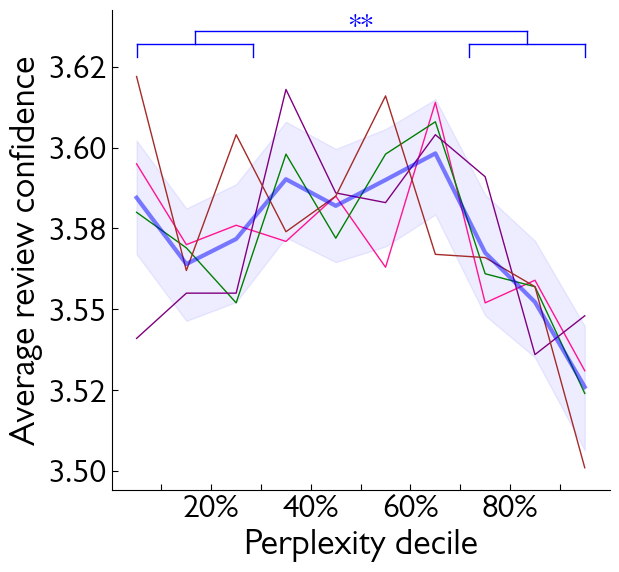

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import bootstrap
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_paths = [
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))

weighted_values = np.zeros(10)
weights = np.zeros(10)

bin_data = {i: [] for i in range(10)}

for file_idx, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    df = pd.read_parquet(file_path)
    df['perplexity_group'] = pd.qcut(df['perplexity'], q=10, labels=False)
    group_stats = df.groupby('perplexity_group').agg({
        'review_avg_confidence': ['mean', 'std'],
        'perplexity': ['min', 'max']
    }).round(3)
    x_values = [(i + 0.5) * 10 for i in range(10)]
    y_values = group_stats['review_avg_confidence']['mean']
    ax.plot(x_values, y_values, linewidth=1, markersize=8, alpha=1, color=color_map[label])
    
    for i in range(10):
        bin_data_i = df[df['perplexity_group'] == i]['review_avg_confidence']
        count = len(bin_data_i)
        
        bin_data[i].extend(bin_data_i.tolist())
        
        weighted_values[i] += y_values[i] * count
        weights[i] += count

weighted_avg = weighted_values / weights

ci_lower = np.zeros(10)
ci_upper = np.zeros(10)

for i in range(10):
    if len(bin_data[i]) > 1:
        try:
            boot_result = bootstrap(
                (np.array(bin_data[i]),), 
                np.mean, 
                confidence_level=0.95,
                random_state=42,
                n_resamples=1000
            )
            ci_lower[i] = boot_result.confidence_interval.low
            ci_upper[i] = boot_result.confidence_interval.high
        except Exception as e:
            print(f"无法计算区间 {i} 的bootstrap CI: {e}")
            std_dev = np.std(bin_data[i])
            ci_lower[i] = weighted_avg[i] - 1.96 * std_dev / np.sqrt(len(bin_data[i]))
            ci_upper[i] = weighted_avg[i] + 1.96 * std_dev / np.sqrt(len(bin_data[i]))
    else:
        ci_lower[i] = weighted_avg[i]
        ci_upper[i] = weighted_avg[i]

ax.plot(x_values, weighted_avg, linewidth=3, color='blue', alpha=0.5)

ax.fill_between(x_values, ci_lower, ci_upper, color='blue', alpha=0.07)

left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.004
top_bracket_height = 0.004
vertical_gap = 0

y_max = max(max(weighted_avg), max(ci_upper))
y_base = y_max + 0.013

x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.0035, "**", 
        ha='center', va='bottom', fontsize=24, color='blue')

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.set_xlabel("Perplexity decile", fontsize=26)
ax.set_ylabel("Average review confidence", fontsize=26)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.subplots_adjust(left=0.12, bottom=0.12, right=0.95, top=0.92)
plt.show()

In [ ]:
# Fig. 2E

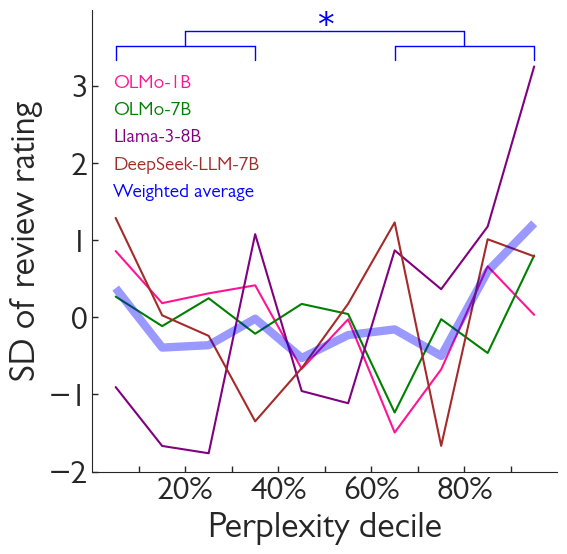

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib
from matplotlib.offsetbox import TextArea, HPacker
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from scipy.stats import norm

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'Gill Sans'
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_paths = [
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-LLM-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-LLM-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_style("ticks")

quantiles = np.linspace(0, 1, 11)
midpoints = (quantiles[:-1] + quantiles[1:]) / 2 * 100

all_std_values = []

legend_labels = []
legend_colors = []

model_data = []

for file_path, label in zip(file_paths, file_labels):
    df = pd.read_parquet(file_path, columns=['perplexity', 'review_avg_rating'])

    df['perplexity'] = pd.to_numeric(df['perplexity'], errors='coerce')
    df['review_avg_rating'] = pd.to_numeric(df['review_avg_rating'], errors='coerce')
    df = df.dropna()

    df['perplexity_group'], bins = pd.qcut(df['perplexity'], q=10, retbins=True, labels=False)

    stats = df.groupby('perplexity_group')['review_avg_rating'].agg(std='std', count='count').reset_index()

    all_std_values.extend(stats['std'].values)
    
    model_data.append({
        'label': label,
        'stats': stats[['perplexity_group', 'std', 'count']].values
    })

    color = color_map.get(label, "black")

    legend_labels.append(label)
    legend_colors.append(color)

mean_std = np.mean(all_std_values)
std_dev_std = np.std(all_std_values)

for model in model_data:
    label = model['label']
    stats = model['stats']
    
    perplexity_groups = stats[:, 0].astype(int)
    std_values = stats[:, 1]
    
    normalized_std = (std_values - mean_std) / std_dev_std
    
    color = color_map.get(label, "black")
    ax.plot(midpoints, normalized_std, linestyle='-', label=label, alpha=1, color=color)

weighted_std_sum = np.zeros(10)
total_counts = np.zeros(10)

for model in model_data:
    stats = model['stats']
    for row in stats:
        bin_idx = int(row[0])
        std_val = row[1]
        count = row[2]
        weighted_std_sum[bin_idx] += std_val * count
        total_counts[bin_idx] += count

weighted_std = np.divide(weighted_std_sum, total_counts, where=total_counts > 0)

normalized_weighted_std = (weighted_std - mean_std) / std_dev_std

n_bootstraps = 1000
bootstrap_samples = np.zeros((n_bootstraps, 10))

for i in range(n_bootstraps):
    sampled_models = np.random.choice(len(model_data), len(model_data), replace=True)
    
    boot_weighted_sum = np.zeros(10)
    boot_total_counts = np.zeros(10)
    
    for model_idx in sampled_models:
        stats = model_data[model_idx]['stats']
        for row in stats:
            bin_idx = int(row[0])
            std_val = row[1]
            count = row[2]
            boot_weighted_sum[bin_idx] += std_val * count
            boot_total_counts[bin_idx] += count
    
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_weighted_avg = np.divide(boot_weighted_sum, boot_total_counts, where=boot_total_counts > 0)
        boot_weighted_avg = np.nan_to_num(boot_weighted_avg)
    
    bootstrap_samples[i] = (boot_weighted_avg - mean_std) / std_dev_std

ci_lower = np.percentile(bootstrap_samples, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_samples, 97.5, axis=0)

ax.plot(midpoints, normalized_weighted_std, linestyle='-', color='blue', linewidth=6, alpha=0.4, label='Weighted Avg', solid_capstyle='butt')

left_bracket_width = 30
right_bracket_width = 30
bracket_height = 0.18
top_bracket_height = 0.2
vertical_gap = 0

y_max = max(max(normalized_weighted_std), max(ci_upper))
y_base = y_max + 0.7

x_left_center = 20
x_right_center = 80

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.15, "*", 
        ha='center', va='bottom', fontsize=24, color='blue')

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('SD of review rating', fontsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.set_ylim(bottom=-2)

ax.set_yticks([-2, -1, 0, 1, 2, 3])

ax.set_ylim(bottom=-2)

ax.tick_params(axis='both', labelsize=24)

legend_handles = [Line2D([0], [0], color=color, lw=0) for color in legend_colors]
legend_labels_show = legend_labels.copy()

legend_handles.append(Line2D([0], [0], color='blue', lw=0))
legend_labels_show.append('Weighted average')
legend_colors_all = legend_colors + ['blue']

ax.legend(handles=legend_handles, 
          labels=legend_labels_show, fontsize=14, 
          bbox_to_anchor=(-0.11, 0.9), loc='upper left', 
          frameon=False, labelcolor=legend_colors_all,
          prop={'family': 'Gill Sans', 'size': 14})

plt.show()

In [ ]:
# Fig. 2F

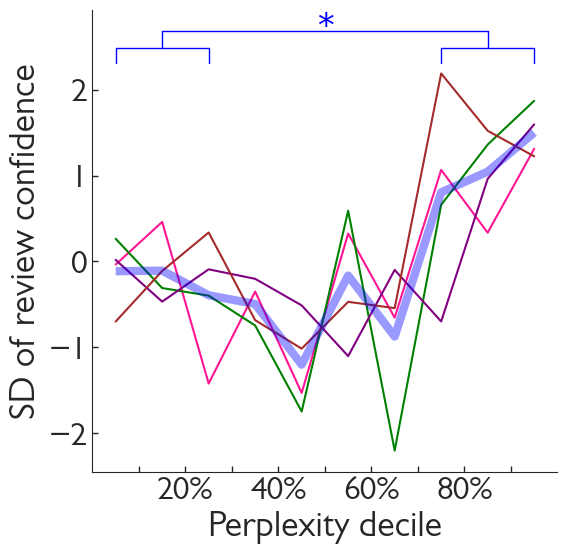

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib
from matplotlib.offsetbox import TextArea, HPacker
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from scipy.stats import norm

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'Gill Sans'
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_paths = [
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_style("ticks")

quantiles = np.linspace(0, 1, 11)
midpoints = (quantiles[:-1] + quantiles[1:]) / 2 * 100

all_std_values = []

legend_labels = []
legend_colors = []

model_data = []

for file_path, label in zip(file_paths, file_labels):
    df = pd.read_parquet(file_path)
    df = df[['perplexity', 'review_avg_confidence']]

    df['perplexity'] = pd.to_numeric(df['perplexity'], errors='coerce')
    df['review_avg_confidence'] = pd.to_numeric(df['review_avg_confidence'], errors='coerce')
    df = df.dropna()

    df['perplexity_group'], bins = pd.qcut(df['perplexity'], q=10, retbins=True, labels=False)

    stats = df.groupby('perplexity_group')['review_avg_confidence'].agg(std='std', count='count').reset_index()

    all_std_values.extend(stats['std'].values)
    
    model_data.append({
        'label': label,
        'stats': stats[['perplexity_group', 'std', 'count']].values
    })

    color = color_map.get(label, "black")

    legend_labels.append(label)
    legend_colors.append(color)

mean_std = np.mean(all_std_values)
std_dev_std = np.std(all_std_values)

for model in model_data:
    label = model['label']
    stats = model['stats']
    
    perplexity_groups = stats[:, 0].astype(int)
    std_values = stats[:, 1]
    
    normalized_std = (std_values - mean_std) / std_dev_std
    
    color = color_map.get(label, "black")
    ax.plot(midpoints, normalized_std, linestyle='-', label=label, alpha=1, color=color)

weighted_std_sum = np.zeros(10)
total_counts = np.zeros(10)

for model in model_data:
    stats = model['stats']
    for row in stats:
        bin_idx = int(row[0])
        std_val = row[1]
        count = row[2]
        weighted_std_sum[bin_idx] += std_val * count
        total_counts[bin_idx] += count

weighted_std = np.divide(weighted_std_sum, total_counts, where=total_counts > 0)

normalized_weighted_std = (weighted_std - mean_std) / std_dev_std

n_bootstraps = 1000
bootstrap_samples = np.zeros((n_bootstraps, 10))

for i in range(n_bootstraps):
    sampled_models = np.random.choice(len(model_data), len(model_data), replace=True)
    
    boot_weighted_sum = np.zeros(10)
    boot_total_counts = np.zeros(10)
    
    for model_idx in sampled_models:
        stats = model_data[model_idx]['stats']
        for row in stats:
            bin_idx = int(row[0])
            std_val = row[1]
            count = row[2]
            boot_weighted_sum[bin_idx] += std_val * count
            boot_total_counts[bin_idx] += count
    
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_weighted_avg = np.divide(boot_weighted_sum, boot_total_counts, where=boot_total_counts > 0)
        boot_weighted_avg = np.nan_to_num(boot_weighted_avg)
    
    bootstrap_samples[i] = (boot_weighted_avg - mean_std) / std_dev_std

ci_lower = np.percentile(bootstrap_samples, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_samples, 97.5, axis=0)

ax.plot(midpoints, normalized_weighted_std, linestyle='-', color='blue', linewidth=6, alpha=0.4, label='Weighted Avg', solid_capstyle='butt')

left_bracket_width = 20
right_bracket_width = 20
bracket_height = 0.18
top_bracket_height = 0.2
vertical_gap = 0

y_max = max(max(normalized_weighted_std), max(ci_upper))
y_base = y_max + 0.5

x_left_center = 15
x_right_center = 85

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.15, "*", 
        ha='center', va='bottom', fontsize=24, color='blue')

ax.set_xlabel('Perplexity decile', fontsize=26)
ax.set_ylabel('SD of review confidence', fontsize=26)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)

ax.tick_params(axis='both', labelsize=24) 

legend_handles = [Line2D([0], [0], color=color, lw=0) for color in legend_colors]
legend_labels_show = legend_labels.copy()

plt.show()

In [9]:
# Fig. 3A

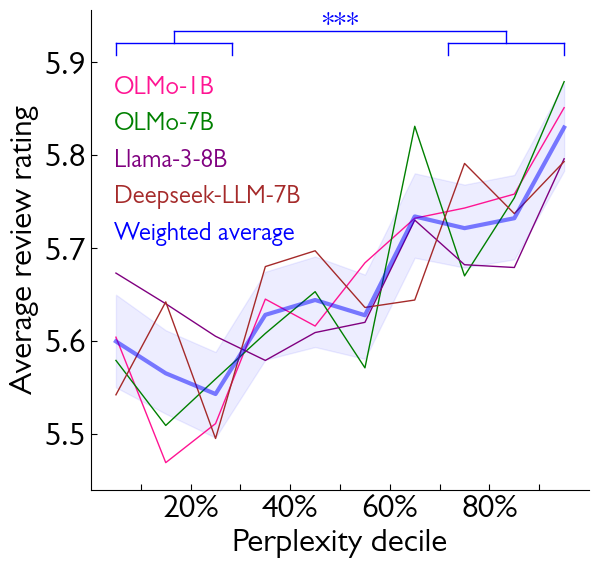

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_paths = [
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]
file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'Deepseek-LLM-7B']
color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'Deepseek-LLM-7B': 'brown'
}

fig, ax = plt.subplots(figsize=(6, 6))

all_data = []

for file_idx, (file_path, label) in enumerate(zip(file_paths, file_labels)):
    df = pd.read_parquet(file_path)
    df['model'] = label
    df['perplexity_group'] = pd.qcut(df['perplexity'], q=10, labels=False)
    all_data.append(df)
    group_stats = df.groupby('perplexity_group').agg({
        'review_avg_rating': ['mean', 'std'],
        'perplexity': ['min', 'max']
    }).round(3)
    
    x_values = [(i + 0.5) * 10 for i in range(10)]  # 每个区间的中心点百分比
    y_values = group_stats['review_avg_rating']['mean']
    
    ax.plot(x_values, y_values, linewidth=1, markersize=8, alpha=1, color=color_map[label])

combined_data = pd.concat(all_data, ignore_index=True)

x_values = [(i + 0.5) * 10 for i in range(10)]

weighted_avg = np.zeros(10)
for i in range(10):
    bin_data = combined_data[combined_data['perplexity_group'] == i]
    if not bin_data.empty:
        weighted_avg[i] = bin_data['review_avg_rating'].mean()

n_bootstraps = 1000
bootstrap_results = np.zeros((n_bootstraps, 10))

for b in range(n_bootstraps):
    for i in range(10):
        bin_data = combined_data[combined_data['perplexity_group'] == i]
        if len(bin_data) > 0:
            bootstrap_sample = bin_data.sample(n=len(bin_data), replace=True)
            bootstrap_results[b, i] = bootstrap_sample['review_avg_rating'].mean()
        else:
            bootstrap_results[b, i] = np.nan

ci_lower = np.percentile(bootstrap_results, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_results, 97.5, axis=0)

ax.plot(x_values, weighted_avg, linewidth=3, color='blue', alpha=0.5)

ax.fill_between(x_values, ci_lower, ci_upper, color='blue', alpha=0.07)

# 可调参数
left_bracket_width = 23.33
right_bracket_width = 23.33
bracket_height = 0.013
top_bracket_height = 0.013
vertical_gap = 0

y_max = max(max(weighted_avg), max(ci_upper))
y_base = y_max + 0.03

# 定义左右方框的位置
x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - left_bracket_width/2
x_left_end = x_left_center + left_bracket_width/2
x_right_start = x_right_center - right_bracket_width/2
x_right_end = x_right_center + right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_left_start, x_left_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_left_end, x_left_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

ax.plot([x_right_start, x_right_start], [y_base, y_base + bracket_height], color='blue', linewidth=1)  # 左边
ax.plot([x_right_start, x_right_end], [y_base + bracket_height, y_base + bracket_height], color='blue', linewidth=1)  # 顶边
ax.plot([x_right_end, x_right_end], [y_base + bracket_height, y_base], color='blue', linewidth=1)    # 右边

y_top_base = y_base + bracket_height + vertical_gap
y_top_top = y_top_base + top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)
ax.plot([x_right_center, x_right_center], [y_base + bracket_height, y_top_base], color='blue', linewidth=1)

ax.plot([x_left_center, x_left_center], [y_top_base, y_top_top], color='blue', linewidth=1)    # 左边
ax.plot([x_left_center, x_right_center], [y_top_top, y_top_top], color='blue', linewidth=1)    # 顶边
ax.plot([x_right_center, x_right_center], [y_top_top, y_top_base], color='blue', linewidth=1)  # 右边

ax.text((x_left_center + x_right_center) / 2, y_top_top - 0.01, "***", 
        ha='center', va='bottom', fontsize=24, color='blue')

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)
ax.set_ylim(bottom=5.44)

ax.set_xlabel("Perplexity decile", fontsize=24)
ax.set_ylabel("Average review rating", fontsize=24)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_labels = file_labels + ['Weighted average']
legend_colors = [color_map[label] for label in file_labels] + ['blue']

ax.legend(
    handles=[Line2D([0], [0], color=color, lw=0) for color in legend_colors],  # 设置 lw=0 使线条不可见
    labels=legend_labels,
    fontsize=18,
    bbox_to_anchor=(-0.14, 0.91),
    loc='upper left',
    frameon=False,
    ncol=1,  # 设置为单列
    labelcolor=legend_colors
)

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 

plt.subplots_adjust(left=0.12, bottom=0.12, right=0.95, top=0.92)
plt.show()

In [1]:
# Fig. 3B

Successfully loaded font: Gill Sans


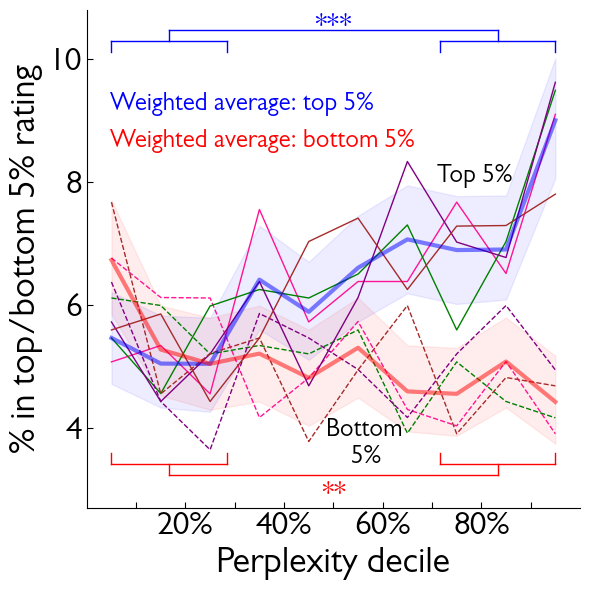

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    print(f"Successfully loaded font: {font_name}")
    
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    print(f"Error loading font: {e}")
    print("Using default font instead")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_paths = [
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo1b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_olmo7b_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_llama3_ppl_rating_confidence_rating-disparity.parquet',
    '/project/jevans/zhenzhang/large_team/data_code/openreview_deepseek_ppl_rating_confidence_rating-disparity.parquet'
]

file_labels = ['OLMo-1B', 'OLMo-7B', 'Llama-3-8B', 'DeepSeek-llm-7B']

color_map = {
    'OLMo-1B': 'deeppink',
    'OLMo-7B': 'green',
    'Llama-3-8B': 'purple',
    'DeepSeek-llm-7B': 'brown'
}

plt.figure(figsize=(6, 6))
ax = plt.gca()
plt.xlabel("Perplexity decile", fontsize=26)
plt.ylabel("% in top/bottom 5% rating", fontsize=26)
plt.grid(False)

all_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax.set_xticks(all_ticks)

ax.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in all_ticks
])

ax.set_xlim(0, 100)
ax.set_ylim(2.5, 10.5)

x_values = np.arange(5, 100, 10)

all_data = []

for file_path, label in zip(file_paths, file_labels):
    df = pd.read_parquet(file_path)
    
    df['perplexity'] = pd.to_numeric(df['perplexity'], errors='coerce')
    df['review_avg_rating'] = pd.to_numeric(df['review_avg_rating'], errors='coerce')
    
    df = df.dropna()
    
    df['model'] = label
    
    df['perplexity_bins'] = pd.qcut(df['perplexity'], 10, labels=False)
    
    all_data.append(df)
    
    threshold_confidence_top = df['review_avg_rating'].quantile(0.95)
    threshold_confidence_bottom = df['review_avg_rating'].quantile(0.05)
    
    percentages_top = np.zeros(10)  
    percentages_bottom = np.zeros(10)  
    
    for bin_idx in range(10):
        subset = df[df['perplexity_bins'] == bin_idx]
        n = len(subset)
        
        if n > 0:
            percentage_top = (subset['review_avg_rating'] >= threshold_confidence_top).sum() / n * 100
            percentage_bottom = (subset['review_avg_rating'] <= threshold_confidence_bottom).sum() / n * 100
            
            percentages_top[bin_idx] = percentage_top
            percentages_bottom[bin_idx] = percentage_bottom

    plt.plot(x_values, percentages_top, linewidth=1, linestyle='-', alpha=1, 
             color=color_map[label])
    plt.plot(x_values, percentages_bottom, linewidth=1, linestyle='--', alpha=1, 
             color=color_map[label])

combined_data = pd.concat(all_data, ignore_index=True)

threshold_all_top = combined_data['review_avg_rating'].quantile(0.95)
threshold_all_bottom = combined_data['review_avg_rating'].quantile(0.05)

weighted_top_avg = np.zeros(10)
weighted_bottom_avg = np.zeros(10)

for bin_idx in range(10):
    bin_data = combined_data[combined_data['perplexity_bins'] == bin_idx]
    if len(bin_data) > 0:
        weighted_top_avg[bin_idx] = (bin_data['review_avg_rating'] >= threshold_all_top).sum() / len(bin_data) * 100
        weighted_bottom_avg[bin_idx] = (bin_data['review_avg_rating'] <= threshold_all_bottom).sum() / len(bin_data) * 100

n_bootstraps = 1000
bootstrap_top = np.zeros((n_bootstraps, 10))
bootstrap_bottom = np.zeros((n_bootstraps, 10))

for b in range(n_bootstraps):
    for bin_idx in range(10):
        bin_data = combined_data[combined_data['perplexity_bins'] == bin_idx]
        if len(bin_data) > 0:
            bootstrap_sample = bin_data.sample(n=len(bin_data), replace=True)
            bootstrap_top[b, bin_idx] = (bootstrap_sample['review_avg_rating'] >= threshold_all_top).sum() / len(bootstrap_sample) * 100
            bootstrap_bottom[b, bin_idx] = (bootstrap_sample['review_avg_rating'] <= threshold_all_bottom).sum() / len(bootstrap_sample) * 100
        else:
            bootstrap_top[b, bin_idx] = np.nan
            bootstrap_bottom[b, bin_idx] = np.nan

ci_lower_top = np.percentile(bootstrap_top, 2.5, axis=0)
ci_upper_top = np.percentile(bootstrap_top, 97.5, axis=0)
ci_lower_bottom = np.percentile(bootstrap_bottom, 2.5, axis=0)
ci_upper_bottom = np.percentile(bootstrap_bottom, 97.5, axis=0)

plt.plot(x_values, weighted_top_avg, linewidth=3, linestyle='-', color='blue', label='Weighted Avg', alpha=0.5)
plt.plot(x_values, weighted_bottom_avg, linewidth=3, linestyle='-', color='red', alpha=0.5)

plt.fill_between(x_values, ci_lower_top, ci_upper_top, color='blue', alpha=0.07)
plt.fill_between(x_values, ci_lower_bottom, ci_upper_bottom, color='red', alpha=0.07)

upper_left_bracket_width = 23.33
upper_right_bracket_width = 23.33
upper_bracket_height = 0.18
upper_top_bracket_height = 0.38
upper_vertical_gap = 0

lower_left_bracket_width = 23.33
lower_right_bracket_width = 23.33
lower_bracket_height = 0.18
lower_top_bracket_height = 0.18
lower_vertical_gap = 0

y_max_top = max(max(weighted_top_avg), max(ci_upper_top))
y_base_upper = y_max_top + 0.1

x_left_center = 16.665
x_right_center = 83.335

x_left_start = x_left_center - upper_left_bracket_width/2
x_left_end = x_left_center + upper_left_bracket_width/2
x_right_start = x_right_center - upper_right_bracket_width/2
x_right_end = x_right_center + upper_right_bracket_width/2

ax.plot([x_left_start, x_left_start], [y_base_upper, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_left_start, x_left_end], [y_base_upper + upper_bracket_height, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_left_end, x_left_end], [y_base_upper + upper_bracket_height, y_base_upper], linewidth=1, color='blue')

ax.plot([x_right_start, x_right_start], [y_base_upper, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_right_start, x_right_end], [y_base_upper + upper_bracket_height, y_base_upper + upper_bracket_height], linewidth=1, color='blue')
ax.plot([x_right_end, x_right_end], [y_base_upper + upper_bracket_height, y_base_upper], linewidth=1, color='blue')

y_top_base_upper = y_base_upper + upper_bracket_height + upper_vertical_gap
y_top_top_upper = y_top_base_upper + upper_top_bracket_height - 0.2

ax.plot([x_left_center, x_left_center], [y_base_upper + upper_bracket_height, y_top_base_upper], linewidth=1, color='blue')
ax.plot([x_right_center, x_right_center], [y_base_upper + upper_bracket_height, y_top_base_upper], linewidth=1, color='blue')

ax.plot([x_left_center, x_left_center], [y_top_base_upper, y_top_top_upper], linewidth=1, color='blue')
ax.plot([x_left_center, x_right_center], [y_top_top_upper, y_top_top_upper], linewidth=1, color='blue')
ax.plot([x_right_center, x_right_center], [y_top_top_upper, y_top_base_upper], linewidth=1, color='blue')

ax.text((x_left_center + x_right_center) / 2, y_top_top_upper - 0.2, "***", 
        ha='center', va='bottom', fontsize=24, color='blue')

y_min_bottom = min(min(weighted_bottom_avg), min(ci_lower_bottom))
y_base_lower = y_min_bottom - 0.15

x_left_start_lower = x_left_center - lower_left_bracket_width/2
x_left_end_lower = x_left_center + lower_left_bracket_width/2
x_right_start_lower = x_right_center - lower_right_bracket_width/2
x_right_end_lower = x_right_center + lower_right_bracket_width/2

ax.plot([x_left_start_lower, x_left_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')
ax.plot([x_left_start_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='red')
ax.plot([x_left_end_lower, x_left_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')

ax.plot([x_right_start_lower, x_right_start_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')
ax.plot([x_right_start_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower - lower_bracket_height], linewidth=1, color='red')
ax.plot([x_right_end_lower, x_right_end_lower], [y_base_lower - lower_bracket_height, y_base_lower], linewidth=1, color='red')

y_top_base_lower = y_base_lower - lower_bracket_height - lower_vertical_gap
y_top_top_lower = y_top_base_lower - lower_top_bracket_height

ax.plot([x_left_center, x_left_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='red')
ax.plot([x_right_center, x_right_center], [y_base_lower - lower_bracket_height, y_top_base_lower], linewidth=1, color='red')

ax.plot([x_left_center, x_left_center], [y_top_base_lower, y_top_top_lower], linewidth=1, color='red')
ax.plot([x_left_center, x_right_center], [y_top_top_lower, y_top_top_lower], linewidth=1, color='red')
ax.plot([x_right_center, x_right_center], [y_top_top_lower, y_top_base_lower], linewidth=1, color='red')

ax.text((x_left_center + x_right_center) / 2, y_top_top_lower - 0.1, "**", 
        ha='center', va='top', fontsize=24, color='red')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    handles=[
        Line2D([0], [0], color='blue', lw=0),
        Line2D([0], [0], color='red', lw=0)
    ],
    labels=['Weighted average: top 5%', 'Weighted average: bottom 5%'],
    fontsize=18,
    bbox_to_anchor=(-0.14, 0.88),
    loc='upper left',
    frameon=False,
    ncol=1,
    labelcolor=['blue', 'red']
)

plt.text(71, 8, 'Top 5%', fontsize=18, color='black')
plt.text(48.6, 3.42, 'Bottom\n    5%', fontsize=18, color='black')

ax.tick_params(axis='both', direction='in', length=4)
ax.tick_params(axis='both', labelsize=24) 
ax.set_ylim(2.7, 10.8)

plt.tight_layout()
plt.show()

In [4]:
# Fig. 3C

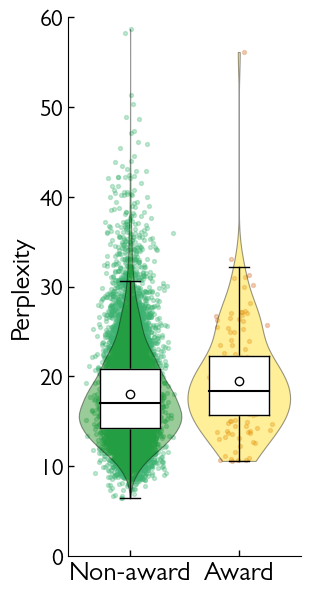

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_path = "/project/jevans/zhenzhang/large_team/data_code/semantic_scholar_ppl_award_olmo1b.parquet"
df = pd.read_parquet(file_path)

df = df.dropna(subset=['perplexity'])

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)

violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

y_max = max([np.max(award_papers), np.max(non_award_papers)])
y_min = min([np.min(award_papers), np.min(non_award_papers)])
y_range = y_max - y_min

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

current_yticks = ax.get_yticks()
plt.yticks(fontsize=17)

yticks_positions = ax.get_yticks()
yticks_labels = [str(int(tick)) if tick == int(tick) else str(tick) for tick in yticks_positions]

ax.set_yticks(yticks_positions)
ax.set_yticklabels(yticks_labels, fontsize=17)

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        ax.tick_params(axis='y', which='major', direction='in', colors='black', length=0, width=1)
        other_ticks = [t for t in yticks_positions if abs(t - 0) >= 1e-10]
        break

class CustomTick:
    def __init__(self, ax):
        self.ax = ax
    
    def set_tick_params(self):
        self.ax.tick_params(axis='y', which='major', direction='in', colors='black', length=4, width=1)
        
        tick_locs = self.ax.yaxis.get_majorticklocs()
        
        for i, loc in enumerate(tick_locs):
            if abs(loc - 0) < 1e-10:
                tick_lines = self.ax.yaxis.get_majorticklines()
                if i*2 < len(tick_lines):
                    tick_lines[i*2].set_markersize(0)
                    tick_lines[i*2].set_markeredgewidth(0)
                if i*2+1 < len(tick_lines):
                    tick_lines[i*2+1].set_markersize(0)
                    tick_lines[i*2+1].set_markeredgewidth(0)

custom_tick = CustomTick(ax)
custom_tick.set_tick_params()

for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(0, 60)

plt.show()

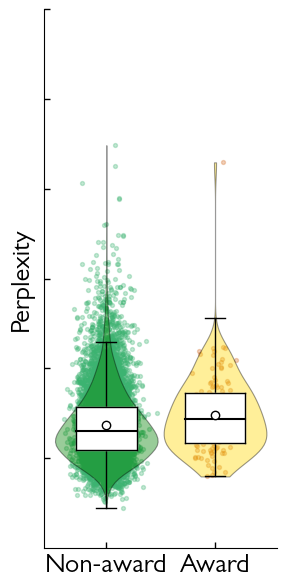

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_path = "/project/jevans/zhenzhang/large_team/data_code/semantic_scholar_ppl_award_olmo7b.parquet"
df = pd.read_parquet(file_path)

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)
violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

yticks_positions = ax.get_yticks()

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        tick_lines = ax.yaxis.get_majorticklines()
        if i*2 < len(tick_lines):
            tick_lines[i*2].set_markersize(0)
            tick_lines[i*2].set_markeredgewidth(0)
        if i*2+1 < len(tick_lines):
            tick_lines[i*2+1].set_markersize(0)
            tick_lines[i*2+1].set_markeredgewidth(0)

plt.yticks(fontsize=17)
for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 60)
ax.set_yticklabels([])

plt.show()

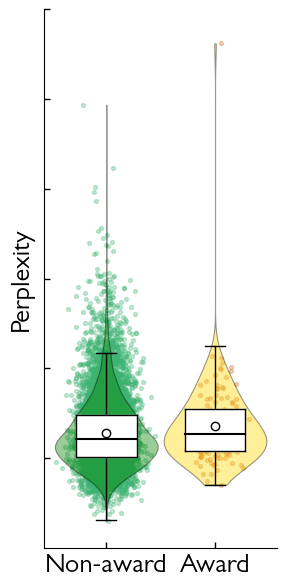

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_path = "/project/jevans/zhenzhang/large_team/data_code/semantic_scholar_ppl_award_llama3.parquet"
df = pd.read_parquet(file_path)

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)
violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

yticks_positions = ax.get_yticks()

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        tick_lines = ax.yaxis.get_majorticklines()
        if i*2 < len(tick_lines):
            tick_lines[i*2].set_markersize(0)
            tick_lines[i*2].set_markeredgewidth(0)
        if i*2+1 < len(tick_lines):
            tick_lines[i*2+1].set_markersize(0)
            tick_lines[i*2+1].set_markeredgewidth(0)

plt.yticks(fontsize=17)
for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 60)
ax.set_yticklabels([])

plt.show()

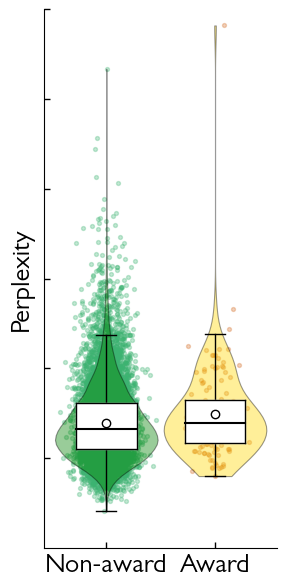

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [font_name, 'Arial', 'DejaVu Sans', 'Liberation Sans']
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

file_path = "/project/jevans/zhenzhang/large_team/data_code/semantic_scholar_ppl_award_deepseek.parquet"
df = pd.read_parquet(file_path)

award_papers = df[df['is_award'] == 1]['perplexity']
non_award_papers = df[df['is_award'] == 0]['perplexity']

data_to_plot = [non_award_papers, award_papers]
labels = ['Non-award', 'Award']

plt.figure(figsize=(3, 7))

plt.rcParams['axes.grid'] = False

positions = [0.5, 0.518]

colors = ['mediumseagreen', 'chocolate']
for i, data in enumerate(data_to_plot):
    x = np.random.normal(positions[i], 0.002, size=len(data))
    plt.scatter(x, data, alpha=0.3, s=8, color=colors[i], zorder=1)

violin_width = 0.017
violin_parts = plt.violinplot(data_to_plot, positions=positions, 
                             showmeans=False, showmedians=False, 
                             showextrema=False, widths=violin_width)
violin_colors = ['green', 'gold']
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(violin_colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.4)
    pc.set_linewidth(0.8)

box_width = 0.01
box_color = 'white'
means = []

for i, data in enumerate(data_to_plot):
    pos = positions[i]
    
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisker_min = max(np.min(data), q1 - 1.5 * iqr)
    whisker_max = min(np.max(data), q3 + 1.5 * iqr)
    
    means.append(np.mean(data))
    
    plt.plot([pos-box_width/2, pos+box_width/2], [q1, q1], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos+box_width/2], [q3, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos-box_width/2, pos-box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    plt.plot([pos+box_width/2, pos+box_width/2], [q1, q3], color='black', linewidth=1, zorder=7)
    
    plt.fill_between([pos-box_width/2, pos+box_width/2], [q1, q1], [q3, q3], color=box_color, zorder=5)
    
    plt.plot([pos-box_width/2, pos+box_width/2], [median, median], color='black', linewidth=1.5, zorder=8)
    
    plt.plot([pos, pos], [q1, whisker_min], color='black', linestyle='-', linewidth=1, zorder=4)
    plt.plot([pos, pos], [q3, whisker_max], color='black', linestyle='-', linewidth=1, zorder=4)
    
    whisker_cap = box_width/3
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_min, whisker_min], color='black', linewidth=1, zorder=4)
    plt.plot([pos-whisker_cap/2, pos+whisker_cap/2], [whisker_max, whisker_max], color='black', linewidth=1, zorder=4)

for i, pos in enumerate(positions):
    plt.plot(pos, means[i], 'o', color='white', markersize=6, markeredgecolor='black', markeredgewidth=1, zorder=9)

plt.xticks(positions, labels, fontsize=19)
plt.ylabel('Perplexity', fontsize=19)

ax = plt.gca()

ax.tick_params(axis='both', which='both', direction='in', colors='black', length=4, width=1)

yticks_positions = ax.get_yticks()

for i, tick_val in enumerate(yticks_positions):
    if abs(tick_val - 0) < 1e-10:
        tick_lines = ax.yaxis.get_majorticklines()
        if i*2 < len(tick_lines):
            tick_lines[i*2].set_markersize(0)
            tick_lines[i*2].set_markeredgewidth(0)
        if i*2+1 < len(tick_lines):
            tick_lines[i*2+1].set_markersize(0)
            tick_lines[i*2+1].set_markeredgewidth(0)

plt.yticks(fontsize=17)
for spine in ax.spines.values():
    spine.set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 60)
ax.set_yticklabels([])

plt.show()

In [16]:
# Fig. 4C

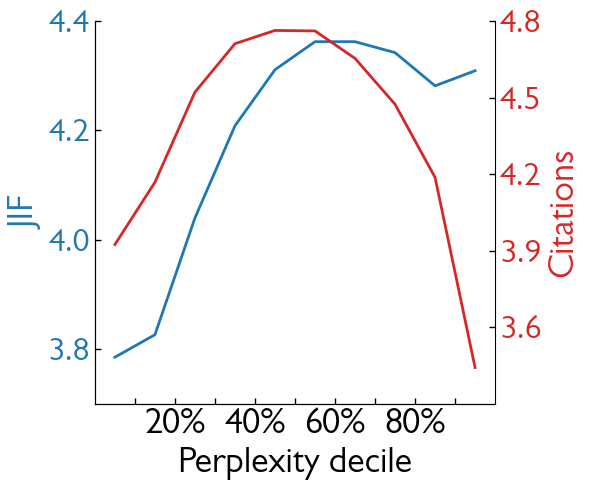

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'Gill Sans'
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

def process_file(file_path):
    df = pd.read_parquet(file_path)
    
    df['perplexity_bins'] = pd.qcut(df['perplexity'], 10)
    
    bin_stats = df.groupby('perplexity_bins').agg({
        'impact_factor_2y': 'mean',
        'citation': 'mean'
    }).reset_index()
    
    midpoints = []
    for interval in bin_stats['perplexity_bins']:
        left = df[df['perplexity'] <= interval.left]['perplexity'].count() / len(df) * 100
        right = df[df['perplexity'] <= interval.right]['perplexity'].count() / len(df) * 100
        midpoints.append((left + right) / 2)
    
    bin_stats['midpoints'] = midpoints
    
    return bin_stats['midpoints'].tolist(), bin_stats['impact_factor_2y'].tolist(), bin_stats['citation'].tolist()

file_paths = [
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_olmo1b_natural_and_social_sciences.parquet",
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_olmo7b_natural_and_social_sciences.parquet", 
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_llama3_natural_and_social_sciences.parquet",
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_deepseek_natural_and_social_sciences.parquet"
]

all_midpoints = []
all_impact_factors = []
all_cites = []

for i, file_path in enumerate(file_paths):
    model_name = file_path.split('/')[-2]
    
    midpoints, impact_factor, cites = process_file(file_path)
    
    all_midpoints.append(midpoints)
    all_impact_factors.append(impact_factor)
    all_cites.append(cites)

all_impact_factors = np.array(all_impact_factors)
all_cites = np.array(all_cites)
all_midpoints = np.array(all_midpoints)

avg_impact_factor = np.mean(all_impact_factors, axis=0)
avg_cites = np.mean(all_cites, axis=0)
avg_midpoints = np.mean(all_midpoints, axis=0)

blue_color = '#1f77b4'
red_color = '#d62728'

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(avg_midpoints, avg_impact_factor, linestyle='-', color=blue_color, linewidth=2, label='Mean Impact Factor 2y')

ax1.set_xlabel('Perplexity decile', fontsize=26)
ax1.set_ylabel('JIF', fontsize=26, color=blue_color)
ax1.tick_params(axis='y', labelcolor=blue_color, labelsize=24)
ax1.set_xlim(0, 100)

ax1.set_ylim(3.7, 4.4)
ax1.set_yticks([3.8, 4.0, 4.2, 4.4])

ax2 = ax1.twinx()

ax2.plot(avg_midpoints, avg_cites, linestyle='-', color=red_color, linewidth=2, label='Mean 2y Citations')

ax2.set_ylabel('Citations', fontsize=26, color=red_color)
ax2.tick_params(axis='y', labelcolor=red_color, labelsize=24)

ax2.set_ylim(3.3, 4.8)
ax2.set_yticks([3.6, 3.9, 4.2, 4.5, 4.8])

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(axis='both', which='both', direction='in', length=4, width=1)
ax2.tick_params(axis='y', direction='in', length=4, width=1)

x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in x_ticks
])
ax1.tick_params(axis='x', labelsize=26)

plt.tight_layout()
plt.show()


In [ ]:
# Fig. 4G

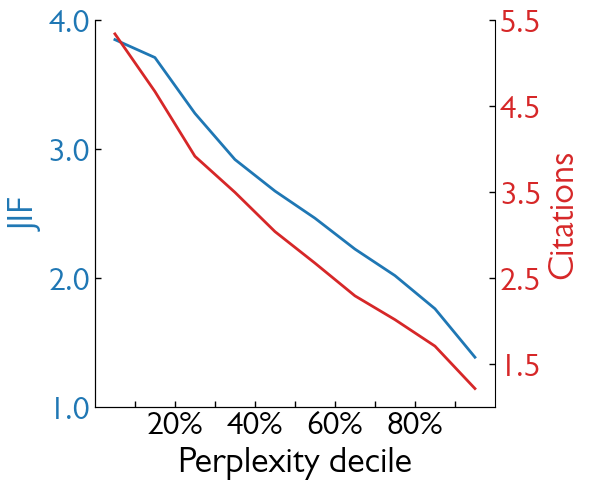

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker

gill_sans_path = '/project/jevans/zhenzhang/font/Gill Sans.otf'
try:
    fm.fontManager.addfont(gill_sans_path)
    prop = fm.FontProperties(fname=gill_sans_path)
    font_name = prop.get_name()
    plt.rcParams['font.family'] = 'Gill Sans'
    
except Exception as e:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

def process_file(file_path):
    df = pd.read_parquet(file_path)
    
    df['perplexity_bins'] = pd.qcut(df['perplexity'], 10)
    
    bin_stats = df.groupby('perplexity_bins').agg({
        'impact_factor_2y': 'mean',
        'citation': 'mean'
    }).reset_index()
    
    midpoints = []
    for interval in bin_stats['perplexity_bins']:
        left = df[df['perplexity'] <= interval.left]['perplexity'].count() / len(df) * 100
        right = df[df['perplexity'] <= interval.right]['perplexity'].count() / len(df) * 100
        midpoints.append((left + right) / 2)
    
    bin_stats['midpoints'] = midpoints
    
    return bin_stats['midpoints'].tolist(), bin_stats['impact_factor_2y'].tolist(), bin_stats['citation'].tolist()

file_paths = [
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_olmo1b_arts_and_humanities.parquet",
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_olmo7b_arts_and_humanities.parquet", 
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_llama3_arts_and_humanities.parquet",
    "/project/jevans/zhenzhang/large_team/data_code/ppl_jif_citation_deepseek_arts_and_humanities.parquet"
]

all_midpoints = []
all_impact_factors = []
all_cites = []

for i, file_path in enumerate(file_paths):
    model_name = file_path.split('/')[-2]
    
    midpoints, impact_factor, cites = process_file(file_path)
    
    all_midpoints.append(midpoints)
    all_impact_factors.append(impact_factor)
    all_cites.append(cites)

all_impact_factors = np.array(all_impact_factors)
all_cites = np.array(all_cites)
all_midpoints = np.array(all_midpoints)

avg_impact_factor = np.mean(all_impact_factors, axis=0)
avg_cites = np.mean(all_cites, axis=0)
avg_midpoints = np.mean(all_midpoints, axis=0)

blue_color = '#1f77b4'
red_color = '#d62728'

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(avg_midpoints, avg_impact_factor, linestyle='-', color=blue_color, linewidth=2, label='Mean Impact Factor 2y')

ax1.set_xlabel('Perplexity decile', fontsize=26)
ax1.set_ylabel('JIF', fontsize=26, color=blue_color)
ax1.tick_params(axis='y', labelcolor=blue_color, labelsize=24)
ax1.set_xlim(0, 100)

ax1.set_ylim(1, 4)
ax1.set_yticks([1.0, 2.0, 3.0, 4.0])
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax1.tick_params(axis='y', which='major', direction='in', length=4, width=1)

ax1_yticks = ax1.yaxis.get_major_ticks()
ax1_yticks[0].tick1line.set_visible(False)

ax2 = ax1.twinx()

ax2.plot(avg_midpoints, avg_cites, linestyle='-', color=red_color, linewidth=2, label='Mean 2y Citations')

ax2.set_ylabel('Citations', fontsize=26, color=red_color)
ax2.tick_params(axis='y', labelcolor=red_color, labelsize=24)

ax2.set_ylim(1, 5.5)
ax2.set_yticks([1.5, 2.5, 3.5, 4.5, 5.5])

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(axis='x', which='both', direction='in', length=4, width=1)
ax2.tick_params(axis='y', direction='in', length=4, width=1)

ax1_yticks = ax1.yaxis.get_major_ticks()
ax1_yticks[0].tick1line.set_visible(False)

x_ticks = [10, 20, 30, 40, 50, 60, 70, 80, 90]
ax1.set_xticks(x_ticks)
ax1.set_xticklabels([
    "20%" if i == 20 else
    "40%" if i == 40 else
    "60%" if i == 60 else
    "80%" if i == 80 else
    ""
    for i in x_ticks
])
ax1.tick_params(axis='x', labelsize=24)

plt.tight_layout()
plt.show()
